# Avaliação dos Resultados do Método Híbrido

Este notebook avalia os métodos individuais (multifoco, estéreo fotométrico e híbrido) e permite a visualização interativa dos resultados.

In [1]:
import os
import glob
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt
import cv2

# Importando a partir do source local
import sys
sys.path.append('/home/lelis/Documents/Projetos/hybrid-stereo-method/src')

from hybrid_stereo_method.infrastructure.io.image_io import read_image, read_fni_to_image_array
from hybrid_stereo_method.infrastructure.visualization import display_image

# Diretórios
EXPERIMENT_DIR = '/home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50'
SHARP_DIR = os.path.join(EXPERIMENT_DIR, 'sharp')
MULTIFOCUS_DIR = os.path.join(EXPERIMENT_DIR, 'multifocus_stereo')
PHOTOMETRIC_DIR = os.path.join(EXPERIMENT_DIR, 'photometric_stereo')
INTEGRATION_DIR = os.path.join(EXPERIMENT_DIR, 'integration')

print(f"Diretório Base: {EXPERIMENT_DIR}")



Diretório Base: /home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50


In [2]:
def compute_angular_error(n_pred, n_gt, valid_mask=None):
    """Calcula o erro angular em graus entre mapas de normais."""
    n_pred_norm = np.clip(np.linalg.norm(n_pred, axis=2, keepdims=True), 1e-8, None)
    n_gt_norm = np.clip(np.linalg.norm(n_gt, axis=2, keepdims=True), 1e-8, None)
    
    n_pred_unit = n_pred / n_pred_norm
    n_gt_unit = n_gt / n_gt_norm
    
    dot_product = np.sum(n_pred_unit * n_gt_unit, axis=2)
    dot_product = np.clip(dot_product, -1.0, 1.0)
    
    angle = np.degrees(np.arccos(dot_product))
    if valid_mask is not None:
        angle = angle * valid_mask
    return angle

def load_normal_gt(filepath):
    """Carrega a normal do sharp, que está no padrão do OpenCV (BGR)"""
    img = cv2.imread(filepath, cv2.IMREAD_UNCHANGED)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    nrm = (img_rgb.astype(np.float32) / 65535.0) * 2.0 - 1.0
    return nrm

def load_height_gt(filepath):
    img = cv2.imread(filepath, cv2.IMREAD_UNCHANGED)
    return img.astype(np.float32) / 65535.0

def viz_results(title, result, error, cmap_res='viridis', cmap_err='hot'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    im1 = axes[0].imshow(result, cmap=cmap_res)
    axes[0].set_title(f"{title} - Z Real")
    plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    axes[0].axis('off')
    
    im2 = axes[1].imshow(error, cmap=cmap_err)
    axes[1].set_title(f"{title} - Diferença para a A. Real do Objeto (Erro)")
    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

def viz_normals(title, pred, gt, error):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow((pred + 1.0) / 2.0)
    axes[0].set_title(f"{title} - Normal Prevista")
    axes[0].axis('off')
    
    axes[1].imshow((gt + 1.0) / 2.0)
    axes[1].set_title(f"{title} - Normal GT")
    axes[1].axis('off')
    
    im3 = axes[2].imshow(error, cmap='jet')
    axes[2].set_title(f"{title} - Erro Angular (°)")
    plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()



## Referência (Ground Truth)

Carregando Referência (Ground Truth)...


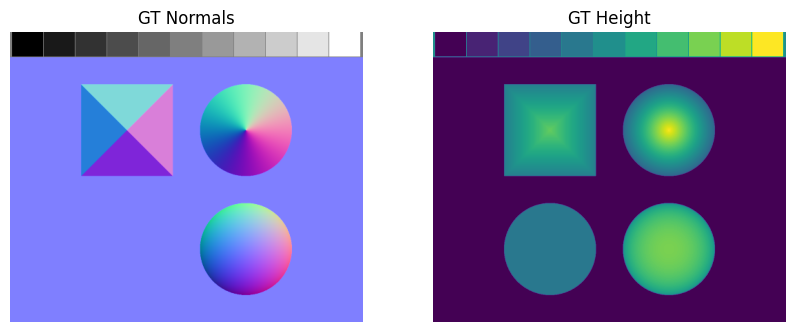

In [ ]:
print("Carregando Referência (Ground Truth)...")

nrm_path = os.path.join(SHARP_DIR, 'sNrm.png')
gt_normals = load_normal_gt(nrm_path)

h_path = os.path.join(SHARP_DIR, 'hAvg.png')
gt_height = load_height_gt(h_path)
h_shape = gt_height.shape

# Máscara (fundo = Z == -1.0 nas normais, ou fundo preto na máscara de profundidade)
valid_mask = (gt_normals[..., 2] > -0.99).astype(np.float32)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.title("GT Normals")
plt.imshow((gt_normals + 1.0) / 2.0)
plt.axis('off')

plt.subplot(122)
plt.title("GT Height")
plt.imshow(gt_height, cmap='viridis')
plt.axis('off')
plt.show()



## 1. Multifocus Stereo
Avaliação do mapa de altura gerado pelo multifoco.

Avaliando Multifocus (Z/Altura)...


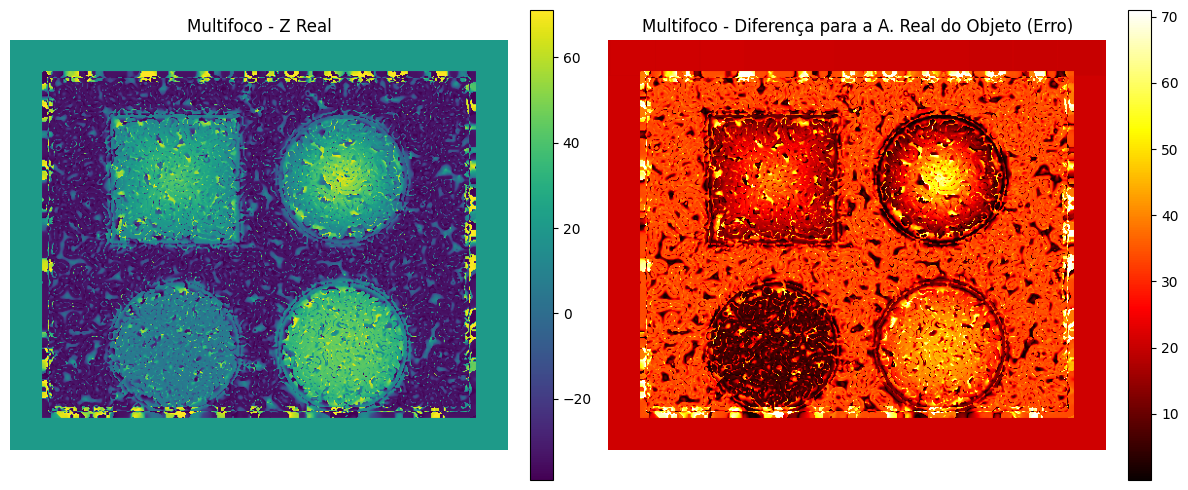

In [21]:
print("Avaliando Multifocus (Z/Altura)...")

zmos_path = os.path.join(MULTIFOCUS_DIR, 'average', 'zMos.fni')
if os.path.exists(zmos_path):
    mf_height = read_fni_to_image_array(zmos_path)
    if len(mf_height.shape) > 2:
        mf_height = mf_height[..., 0]
    
    # Recortar o array caso o tamanho seja um pouco maior devido à integração em malha/bordas
    mf_height = mf_height[:h_shape[0], :h_shape[1]]
    
    # Alinha ambos pela média da parte válida para avaliar quão diferente ficas o relevo globalmente
    mf_h_mean = np.mean(mf_height[valid_mask > 0])
    gt_h_mean = np.mean(gt_height[valid_mask > 0])

    mf_height_aligned = mf_height - mf_h_mean + gt_h_mean
    
    mf_error = np.abs(mf_height_aligned - gt_height) #* valid_mask
    viz_results('Multifoco', mf_height_aligned, mf_error)
else:
    print(f"Arquivo não encontrado: {zmos_path}")



Avaliando Multifocus (Z/Altura)...


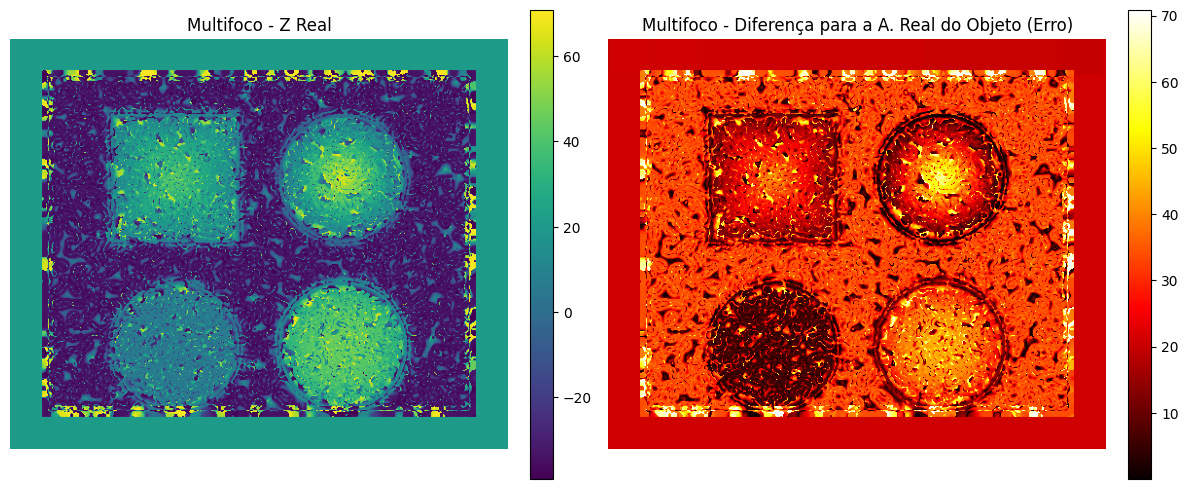

In [ ]:
print("Avaliando Multifocus (Z/Altura)...")

zmos_path = os.path.join(MULTIFOCUS_DIR, 'average', 'zMos.fni')
if os.path.exists(zmos_path):
    mf_height = read_fni_to_image_array(zmos_path)
    if len(mf_height.shape) > 2:
        mf_height = mf_height[..., 0]
    
    # Recortar o array caso o tamanho seja um pouco maior devido à integração em malha/bordas
    mf_height = mf_height[:h_shape[0], :h_shape[1]]
    
    # Alinha ambos pela média da parte válida para avaliar quão diferente ficas o relevo globalmente
    mf_h_mean = np.mean(mf_height[valid_mask > 0])
    gt_h_mean = np.mean(gt_height[valid_mask > 0])

    mf_h_mean = np.mean(mf_height)
    gt_h_mean = np.mean(gt_height)
    mf_height_aligned = mf_height - mf_h_mean + gt_h_mean
    
    mf_error = np.abs(mf_height_aligned - gt_height) #* valid_mask
    viz_results('Multifoco', mf_height_aligned, mf_error)
else:
    print(f"Arquivo não encontrado: {zmos_path}")



## 2. Photometric Stereo
Avaliação das normais obtidas no passo fotométrico.

Avaliando Photometric Stereo (Normais)...


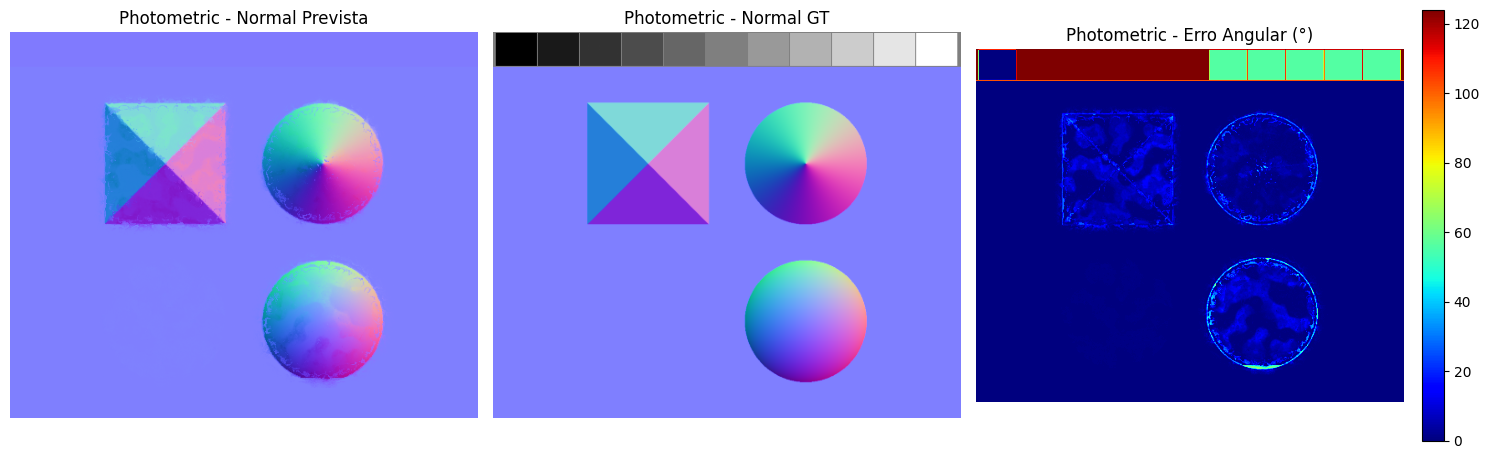

In [5]:
print("Avaliando Photometric Stereo (Normais)...")

ps_nrm_npy = os.path.join(PHOTOMETRIC_DIR, 'normal_map.npy')
ps_nrm_fni = os.path.join(PHOTOMETRIC_DIR, 'normal_map_with_residuals.fni')

ps_normals = None
if os.path.exists(ps_nrm_npy):
    ps_normals = np.load(ps_nrm_npy)
elif os.path.exists(ps_nrm_fni):
    ps_data = read_fni_to_image_array(ps_nrm_fni)
    ps_normals = ps_data[..., :3]

if ps_normals is not None:
    ps_normals = ps_normals[:h_shape[0], :h_shape[1]]
    ps_error = compute_angular_error(ps_normals, gt_normals, valid_mask)
    viz_normals('Photometric', ps_normals, gt_normals, ps_error)
else:
    print("Normal map do photometric stereo não encontrado.")



## 3. Método Híbrido
Avaliação do resultado final de altura e normais pós integração.

Avaliando Método Híbrido Final...


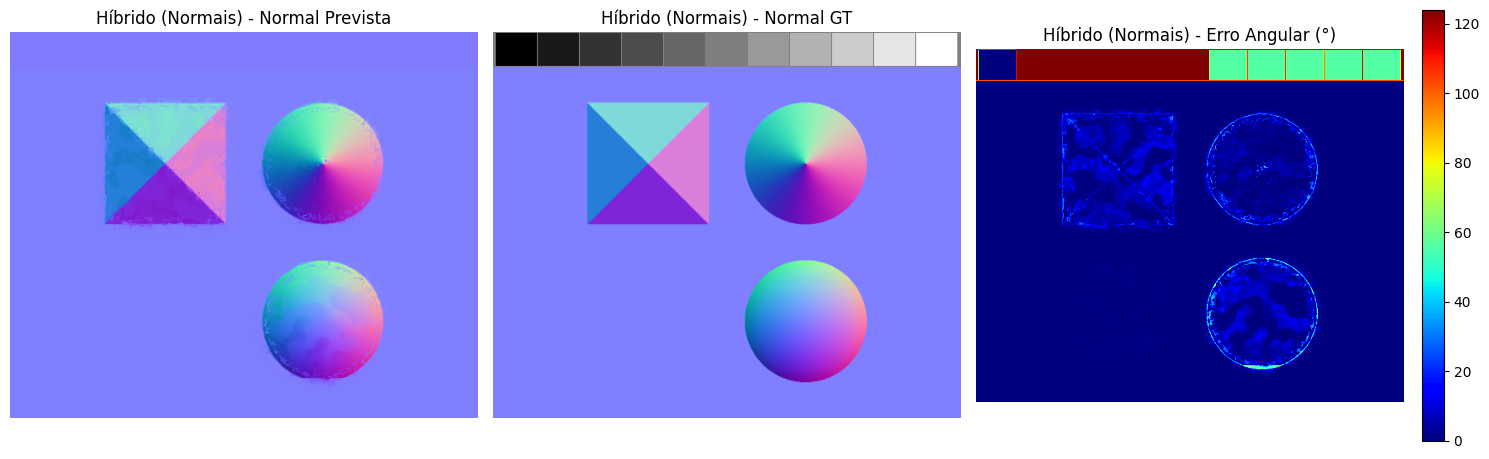

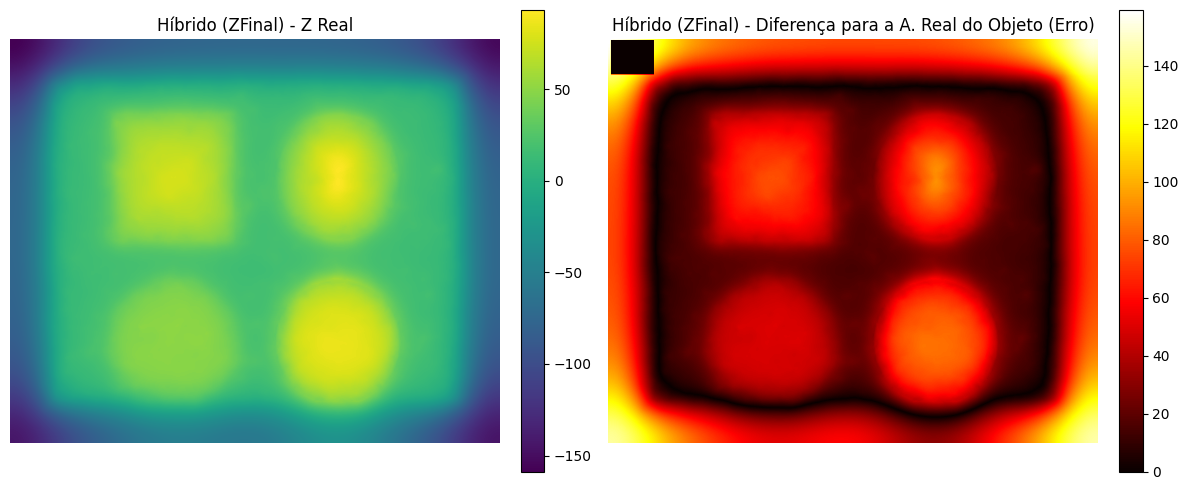

In [6]:
print("Avaliando Método Híbrido Final...")

hb_nrm_fni = os.path.join(INTEGRATION_DIR, 'height_normals.fni')
if os.path.exists(hb_nrm_fni):
    hb_normals = read_fni_to_image_array(hb_nrm_fni)[..., :3]
    hb_normals = hb_normals[:h_shape[0], :h_shape[1]]
    
    hb_nrm_error = compute_angular_error(hb_normals, gt_normals, valid_mask)
    viz_normals('Híbrido (Normais)', hb_normals, gt_normals, hb_nrm_error)
else:
    print("Normais do método híbrido não encontradas.")

# O ZFinal
zmos_final = None

for file_cand in ['height_map.npy', 'height_map.fni']:
    p = os.path.join(INTEGRATION_DIR, file_cand)
    if os.path.exists(p):
        if p.endswith('.npy'): zmos_final = np.load(p)
        else: zmos_final = read_fni_to_image_array(p)
        break

if zmos_final is None:
    fallback = glob.glob(os.path.join(INTEGRATION_DIR, 'height-*end-Z.fni'))
    if fallback:
        fallback.sort()
        zmos_final = read_fni_to_image_array(fallback[-1])

if zmos_final is not None:
    if len(zmos_final.shape) > 2:
        zmos_final = zmos_final[..., 0]
        
    # Recortar pois Z integrado geralmente ganha +1 em cada dimensão M+1 x N+1
    zmos_final = zmos_final[:h_shape[0], :h_shape[1]]
    
    hb_h_mean = np.mean(zmos_final[valid_mask > 0])
    hb_height_aligned = zmos_final - hb_h_mean + gt_h_mean
    
    hb_h_error = np.abs(hb_height_aligned - gt_height) * valid_mask
    viz_results('Híbrido (ZFinal)', hb_height_aligned, hb_h_error)
else:
    print("Height map híbrido final não encontrado.")



## Visualização de Iteraçoes
Na parte do hybrido quero visualizar as iteraçoes, com as imagens de iteração no msm grafico(ex: Z e erro).

Plotando iterações do método híbrido (Z e Erro GT)...


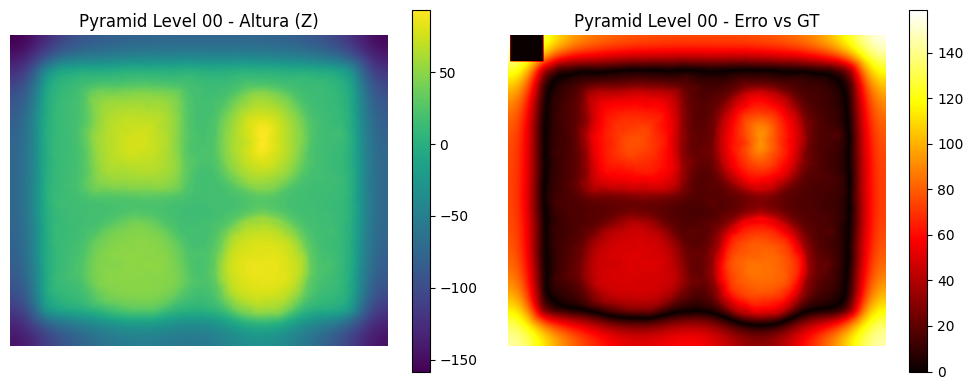

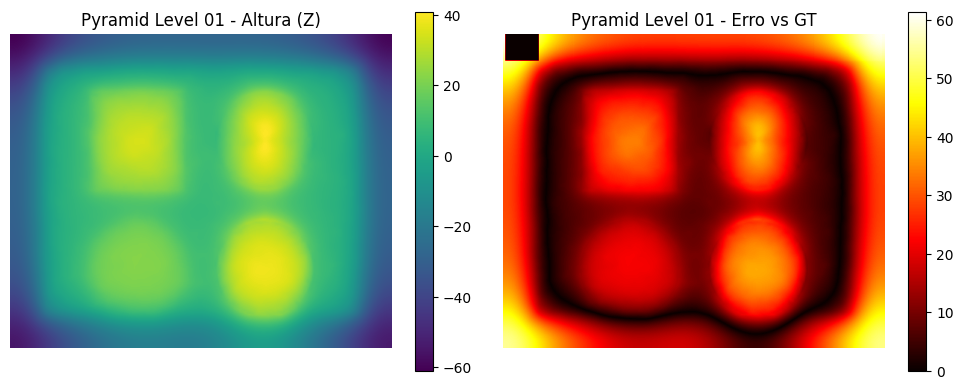

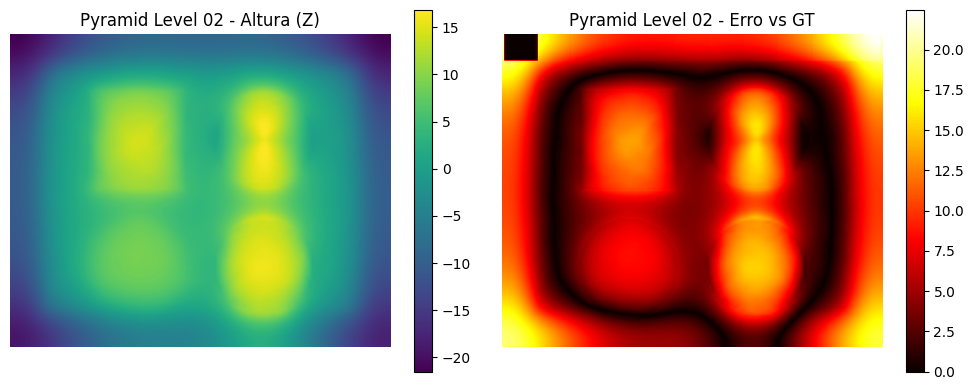

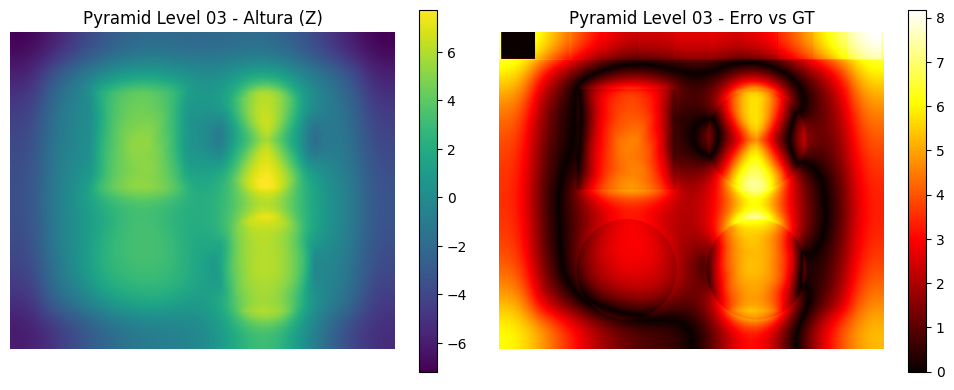

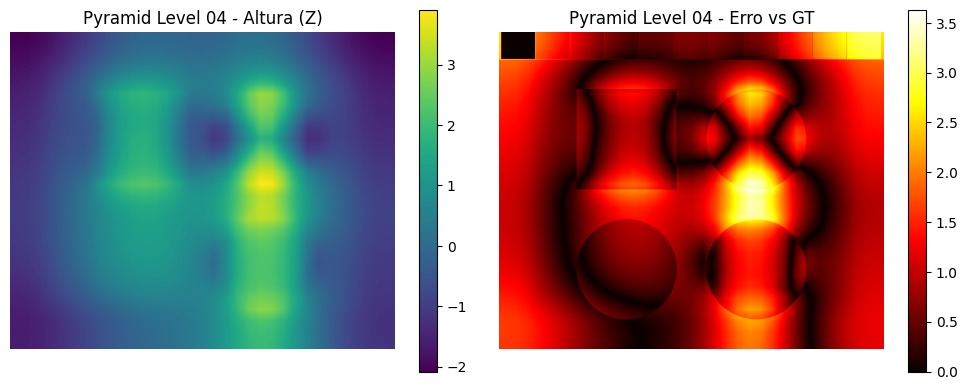

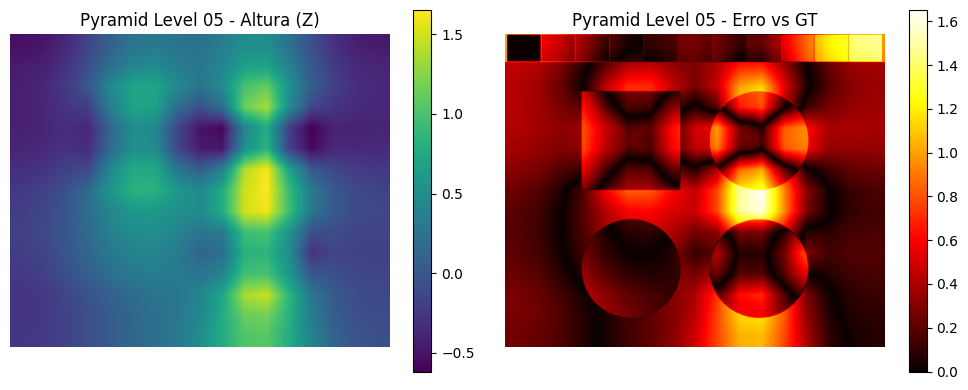

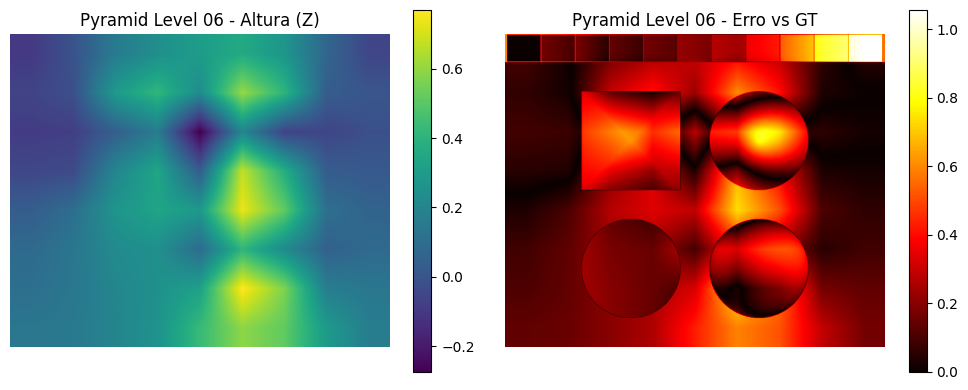

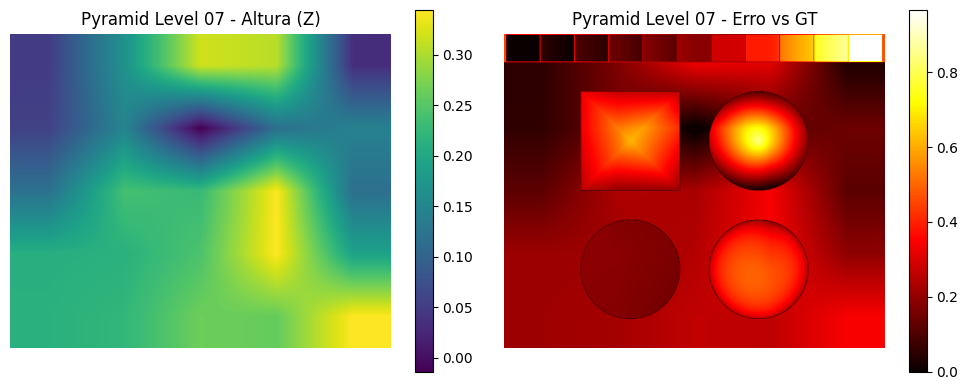

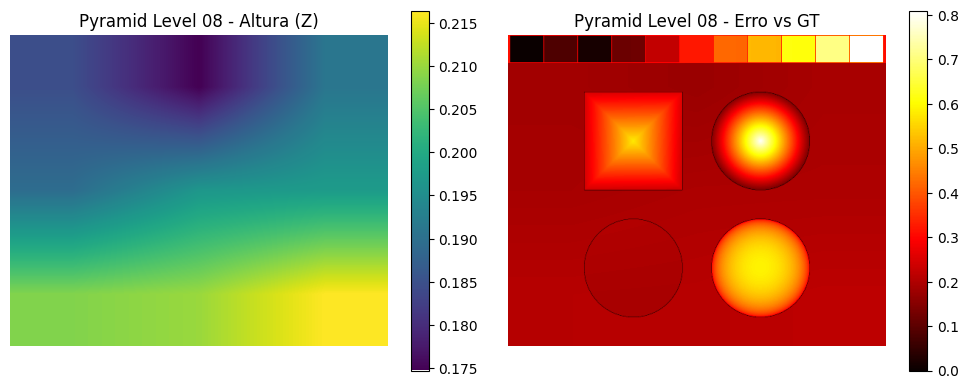

In [22]:

print("Plotando iterações do método híbrido (Z e Erro GT)...")

files = glob.glob(os.path.join(INTEGRATION_DIR, 'height-*end-Z.fni'))
# Note: Iterações do arquivo C usam numeração no formato pyramid level. level 00 é a maior resolução.
files.sort()

if not files:
    print("Nenhum arquivo de iteração encontrado. Ex: height-00-end-Z.fni.")
else:
    for file_path in files:
        filename = os.path.basename(file_path)
        iter_match = re.search(r'height-(\d+)-end-Z.fni', filename)
        iter_num = iter_match.group(1) if iter_match else "?"
        
        z_map = read_fni_to_image_array(file_path)
        if len(z_map.shape) > 2:
            z_map = z_map[..., 0]
            
        # Como o grid integration tem múltiplas resoluções, vamos fazer o resize upscale para comparar o erro
        if z_map.shape[0] != h_shape[0] or z_map.shape[1] != h_shape[1]:
            z_map_resized = cv2.resize(z_map, (h_shape[1], h_shape[0]), interpolation=cv2.INTER_LINEAR)
        else:
            z_map_resized = z_map

        # Alinhar Z da iteracao em relação GT para aval. local
        z_mean = np.mean(z_map_resized[valid_mask > 0])
        z_aligned = z_map_resized - z_mean + gt_h_mean
        
        err = np.abs(z_aligned - gt_height) * valid_mask
        
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        
        # Plot Z
        im_z = axes[0].imshow(z_aligned, cmap='viridis')
        axes[0].set_title(f"Pyramid Level {iter_num} - Altura (Z)")
        plt.colorbar(im_z, ax=axes[0])
        axes[0].axis('off')
        
        # Plot Error
        im_e = axes[1].imshow(err, cmap='hot')
        axes[1].set_title(f"Pyramid Level {iter_num} - Erro vs GT")
        plt.colorbar(im_e, ax=axes[1])
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()



Plotando iterações do método híbrido (Z e E)...


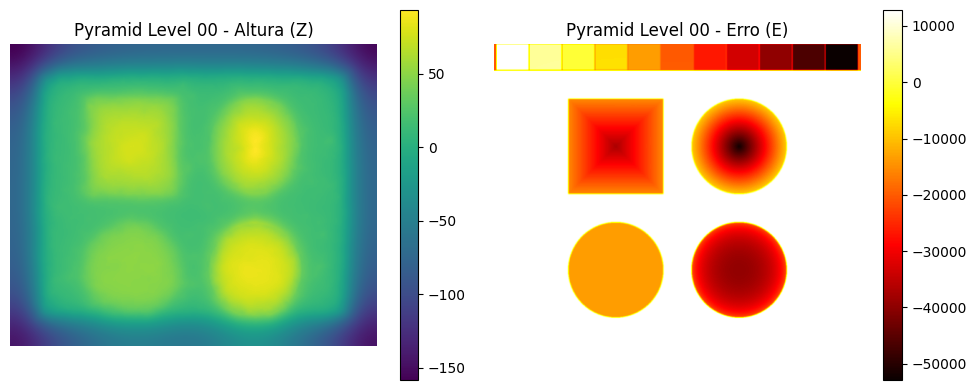

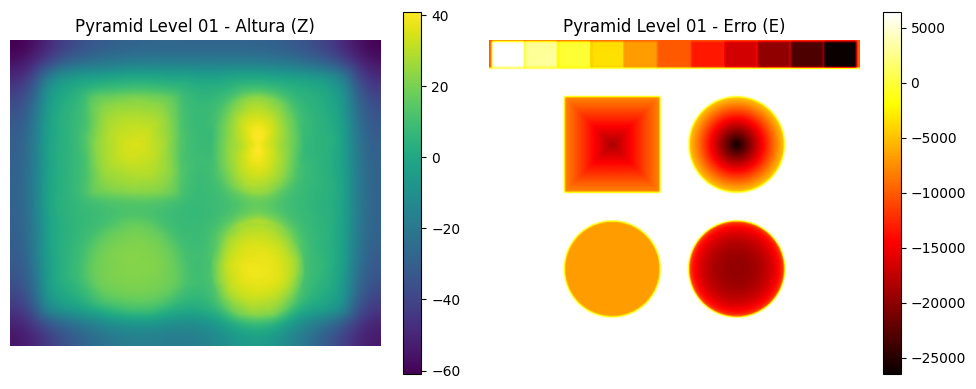

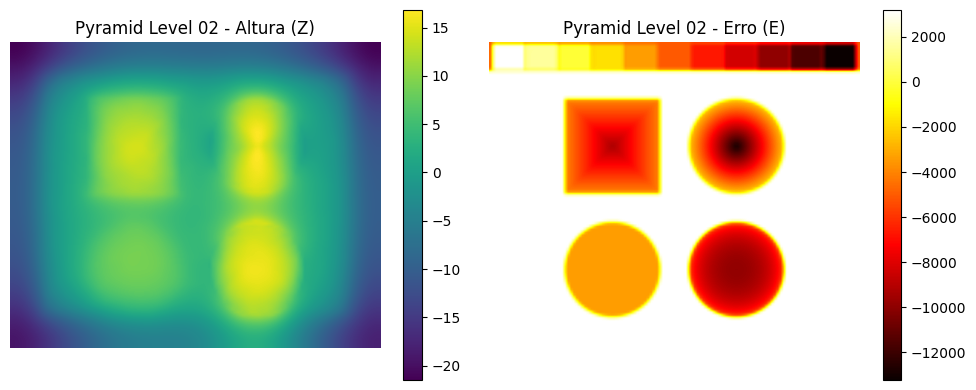

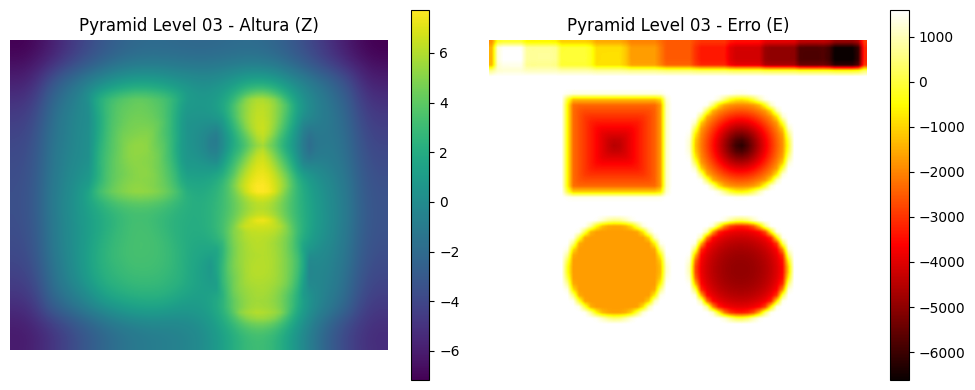

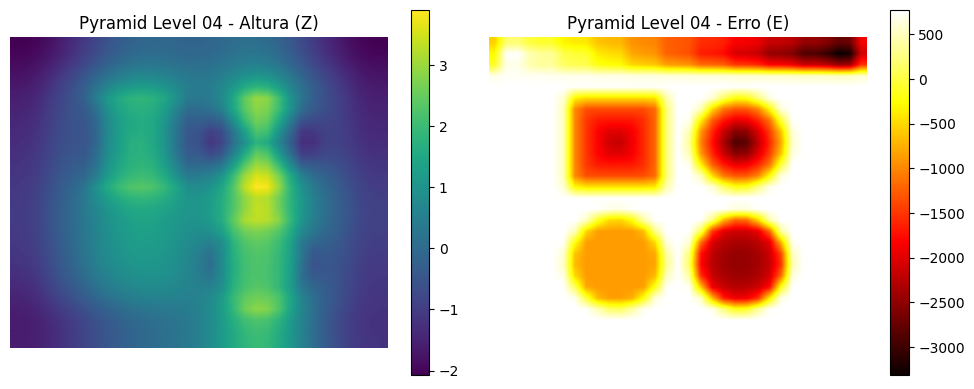

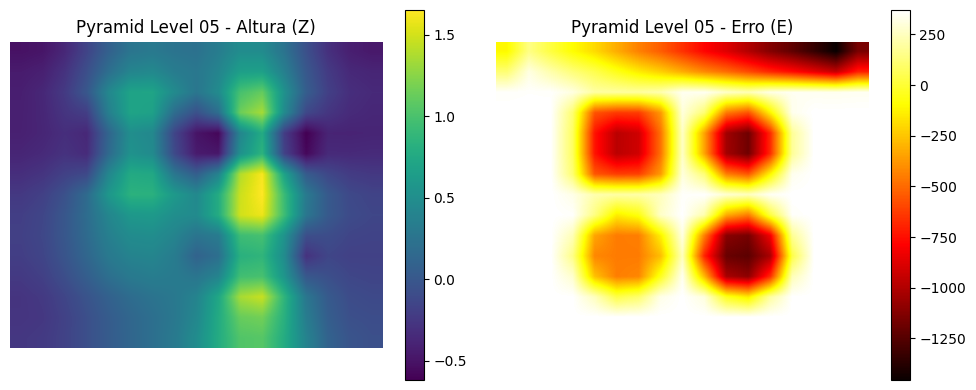

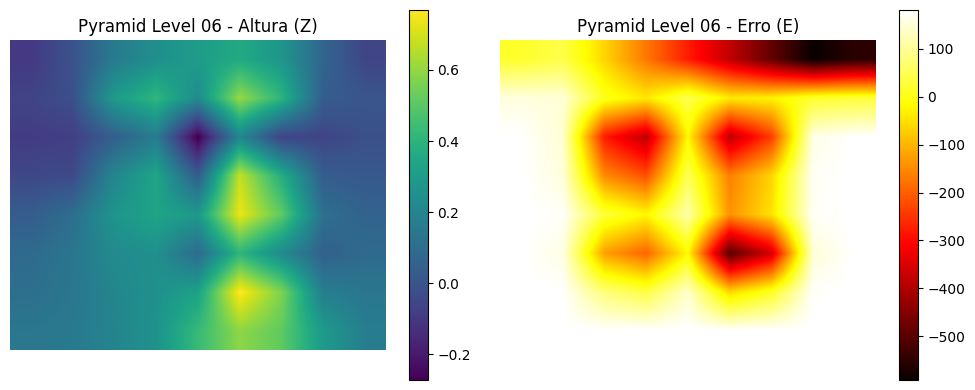

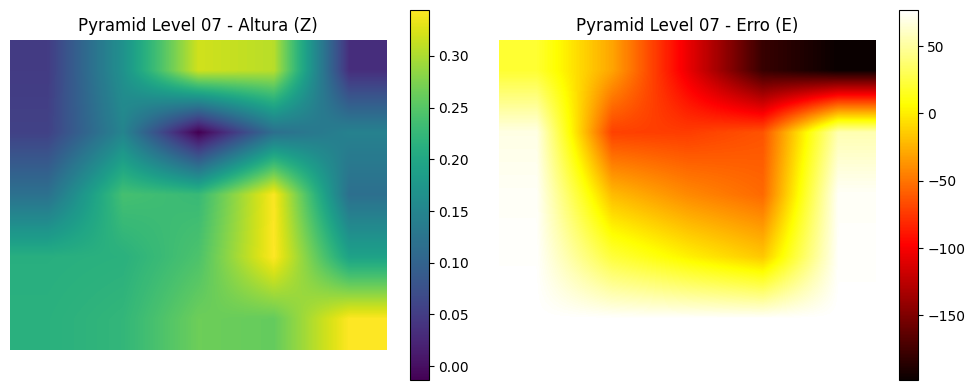

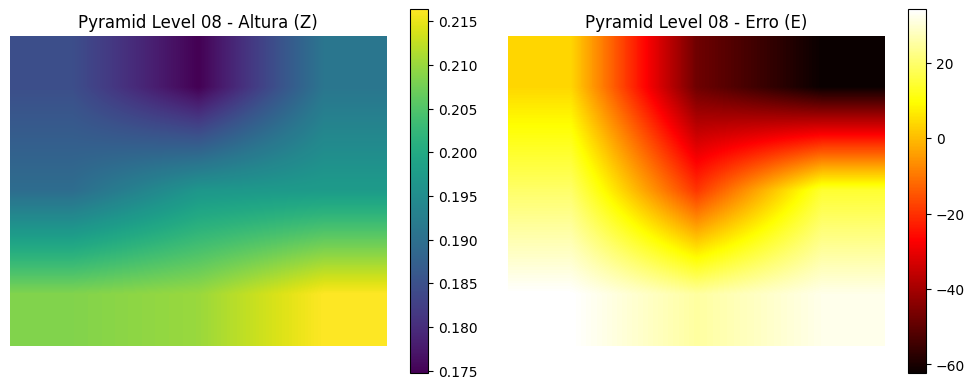

In [23]:
print("Plotando iterações do método híbrido (Z e E)...")

z_files = glob.glob(os.path.join(INTEGRATION_DIR, 'height-*end-Z.fni'))
z_files.sort()

if not z_files:
    print("Nenhum arquivo Z encontrado. Ex: height-00-end-Z.fni.")
else:
    for z_path in z_files:
        filename = os.path.basename(z_path)
        m = re.search(r'height-(\d+)-end-Z\.fni', filename)
        level = m.group(1) if m else "?"
        
        # Arquivo E correspondente ao mesmo nível
        e_path = os.path.join(INTEGRATION_DIR, f'height-{level}-end-E.fni')

        # --- Z ---
        z_map = read_fni_to_image_array(z_path)
        if z_map.ndim > 2:
            z_map = z_map[..., 0]

        if z_map.shape[:2] != h_shape:
            z_map = cv2.resize(z_map, (h_shape[1], h_shape[0]), interpolation=cv2.INTER_LINEAR)

        # Alinhamento opcional de média para manter comparável ao GT
        z_mean = np.mean(z_map[valid_mask > 0])
        z_plot = z_map - z_mean + gt_h_mean

        # --- E ---
        e_map = None
        if os.path.exists(e_path):
            e_map = read_fni_to_image_array(e_path)
            if e_map.ndim > 2:
                e_map = e_map[..., 0]

            if e_map.shape[:2] != h_shape:
                e_map = cv2.resize(e_map, (h_shape[1], h_shape[0]), interpolation=cv2.INTER_LINEAR)

        # --- Plot ---
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        im_z = axes[0].imshow(z_plot, cmap='viridis')
        axes[0].set_title(f"Pyramid Level {level} - Altura (Z)")
        plt.colorbar(im_z, ax=axes[0])
        axes[0].axis('off')

        if e_map is not None:
            im_e = axes[1].imshow(e_map, cmap='hot')
            axes[1].set_title(f"Pyramid Level {level} - Erro (E)")
            plt.colorbar(im_e, ax=axes[1])
            axes[1].axis('off')
        else:
            axes[1].set_title(f"Pyramid Level {level} - Erro (E) não encontrado")
            axes[1].axis('off')

        plt.tight_layout()
        plt.show()
